In [4]:
!pip install networkx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ------------------------- -------------- 1.3/2.1 MB 4.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1 -> 26.1.2
[notice] To update, run: C:\Users\Huy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import pulp
import pandas as pd
import numpy as np

### 1. Generate Data and Testing

In [ ]:
# 1. KHỞI TẠO DỮ LIỆU (3 NĂM)
YEARS = [1, 2, 3]
CLIENTS = ["C1", "C2", "C3", "C4", "C5"]
DEPOTS = ["D1", "D2", "D3"]

# Kịch bản nhu cầu: Tăng trưởng bùng nổ vào Năm 2 và Năm 3
demand = {
    1: {"C1": 10, "C2": 15, "C3": 12, "C4": 20, "C5": 18},
    2: {"C1": 18, "C2": 25, "C3": 20, "C4": 30, "C5": 28},
    3: {"C1": 35, "C2": 45, "C3": 38, "C4": 50, "C5": 42}
}

# Thông số của các kho tiềm năng
# D1: Kho nhỏ, rẻ, phù hợp lúc khởi nghiệp
# D2: Kho cỡ trung bình
# D3: Siêu tổng kho (Mega-DC), rất đắt nhưng sức chứa khổng lồ
depot_data = {
    "D1": {"capacity": 80, "operating_cost": 100, "opening_cost": 200, "closing_cost": 50},
    "D2": {"capacity": 150, "operating_cost": 180, "opening_cost": 350, "closing_cost": 80},
    "D3": {"capacity": 300, "operating_cost": 300, "opening_cost": 600, "closing_cost": 150}
}

# Ma trận khoảng cách (Chi phí vận chuyển)
dist_matrix = {
    "C1": {"D1": 2, "D2": 5, "D3": 8},
    "C2": {"D1": 3, "D2": 4, "D3": 7},
    "C3": {"D1": 6, "D2": 2, "D3": 5},
    "C4": {"D1": 8, "D2": 3, "D3": 4},
    "C5": {"D1": 9, "D2": 6, "D3": 2}
}
TRANSPORT_COST_PER_UNIT = 1.5

### 2.Build Up Dynamic Model

In [ ]:
# 2. XÂY DỰNG MÔ HÌNH DYNAMIC
# =========================
model = pulp.LpProblem("Dynamic_Facility_Location", pulp.LpMinimize)

# Các biến quyết định (Thêm chiều thời gian t)
y = pulp.LpVariable.dicts("Active", (DEPOTS, YEARS), cat="Binary")       # Đang hoạt động
open_var = pulp.LpVariable.dicts("Open", (DEPOTS, YEARS), cat="Binary")  # Hành động mở mới
close_var = pulp.LpVariable.dicts("Close", (DEPOTS, YEARS), cat="Binary")# Hành động đóng cửa
x = pulp.LpVariable.dicts("Flow", (CLIENTS, DEPOTS, YEARS), lowBound=0, cat="Continuous") # Luồng hàng


### 3. Constraints

In [ ]:
# 3. HÀM MỤC TIÊU & RÀNG BUỘC
# Hàm mục tiêu: Tổng chi phí 3 năm = Vận hành + Xây mới + Đóng cửa + Vận chuyển
model += pulp.lpSum(
    depot_data[j]["operating_cost"] * y[j][t] +
    depot_data[j]["opening_cost"] * open_var[j][t] +
    depot_data[j]["closing_cost"] * close_var[j][t]
    for j in DEPOTS for t in YEARS
) + pulp.lpSum(
    TRANSPORT_COST_PER_UNIT * dist_matrix[i][j] * x[i][j][t]
    for i in CLIENTS for j in DEPOTS for t in YEARS
)

# Ràng buộc 1: Cân bằng trạng thái theo thời gian (State Transition)
for j in DEPOTS:
    for t in YEARS:
        if t == 1:
            # Năm đầu tiên: Trạng thái hoạt động đúng bằng quyết định mở mới
            model += y[j][t] == open_var[j][t]
        else:
            # Các năm sau: Trạng thái hiện tại = Trạng thái năm ngoái + Mở mới - Đóng cửa
            model += y[j][t] == y[j][t-1] + open_var[j][t] - close_var[j][t]

# Ràng buộc 2: Khách hàng phải được phục vụ đủ nhu cầu TRONG TỪNG NĂM
for t in YEARS:
    for i in CLIENTS:
        model += pulp.lpSum(x[i][j][t] for j in DEPOTS) == demand[t][i]

# Ràng buộc 3: Công suất tối đa TRONG TỪNG NĂM
for t in YEARS:
    for j in DEPOTS:
        model += pulp.lpSum(x[i][j][t] for i in CLIENTS) <= depot_data[j]["capacity"] * y[j][t]

### 4. In RoadMap Solving

In [ ]:
# 4. GIẢI BÀI TOÁN & IN ROADMAP
print("Đang giải mô hình MP-DFLP...")
model.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"Trạng thái: {pulp.LpStatus[model.status]}")
print(f"Tổng chi phí vòng đời (TCO) trong {len(YEARS)} năm: ${pulp.value(model.objective):,.2f}\n")

print("="*60)
print("BẢN ĐỒ CHIẾN LƯỢC MẠNG LƯỚI KHO BÃI (3-YEAR ROADMAP)")
print("="*60)

for t in YEARS:
    print(f"\n⏳ KẾ HOẠCH NĂM {t}:")
    print("-" * 30)
    
    total_demand = sum(demand[t][i] for i in CLIENTS)
    print(f"Tổng nhu cầu thị trường: {total_demand} đơn vị")
    
    # Liệt kê các hành động (Action)
    for j in DEPOTS:
        if pulp.value(open_var[j][t]) > 0.5:
            print(f"  [+] HÀNH ĐỘNG: Đầu tư xây dựng/Thuê mới kho {j} (Sức chứa: {depot_data[j]['capacity']})")
        if pulp.value(close_var[j][t]) > 0.5:
            print(f"  [-] HÀNH ĐỘNG: Đóng cửa/Thanh lý kho {j} (Mất phí phá vỡ hợp đồng)")
            
    # Hiển thị trạng thái hoạt động và hiệu suất
    active_depots = [j for j in DEPOTS if pulp.value(y[j][t]) > 0.5]
    print(f"  Kho đang vận hành: {', '.join(active_depots)}")
    
    for j in active_depots:
        used = sum(pulp.value(x[i][j][t]) for i in CLIENTS)
        cap = depot_data[j]['capacity']
        print(f"      • {j}: Xử lý {used}/{cap} đơn vị (Hiệu suất: {used/cap:.1%})")

### 5. Visualizing the strategy (3y)

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

C:\Users\Huy\AppData\Local\Temp\ipykernel_13012\3971929018.py:110: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\Huy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


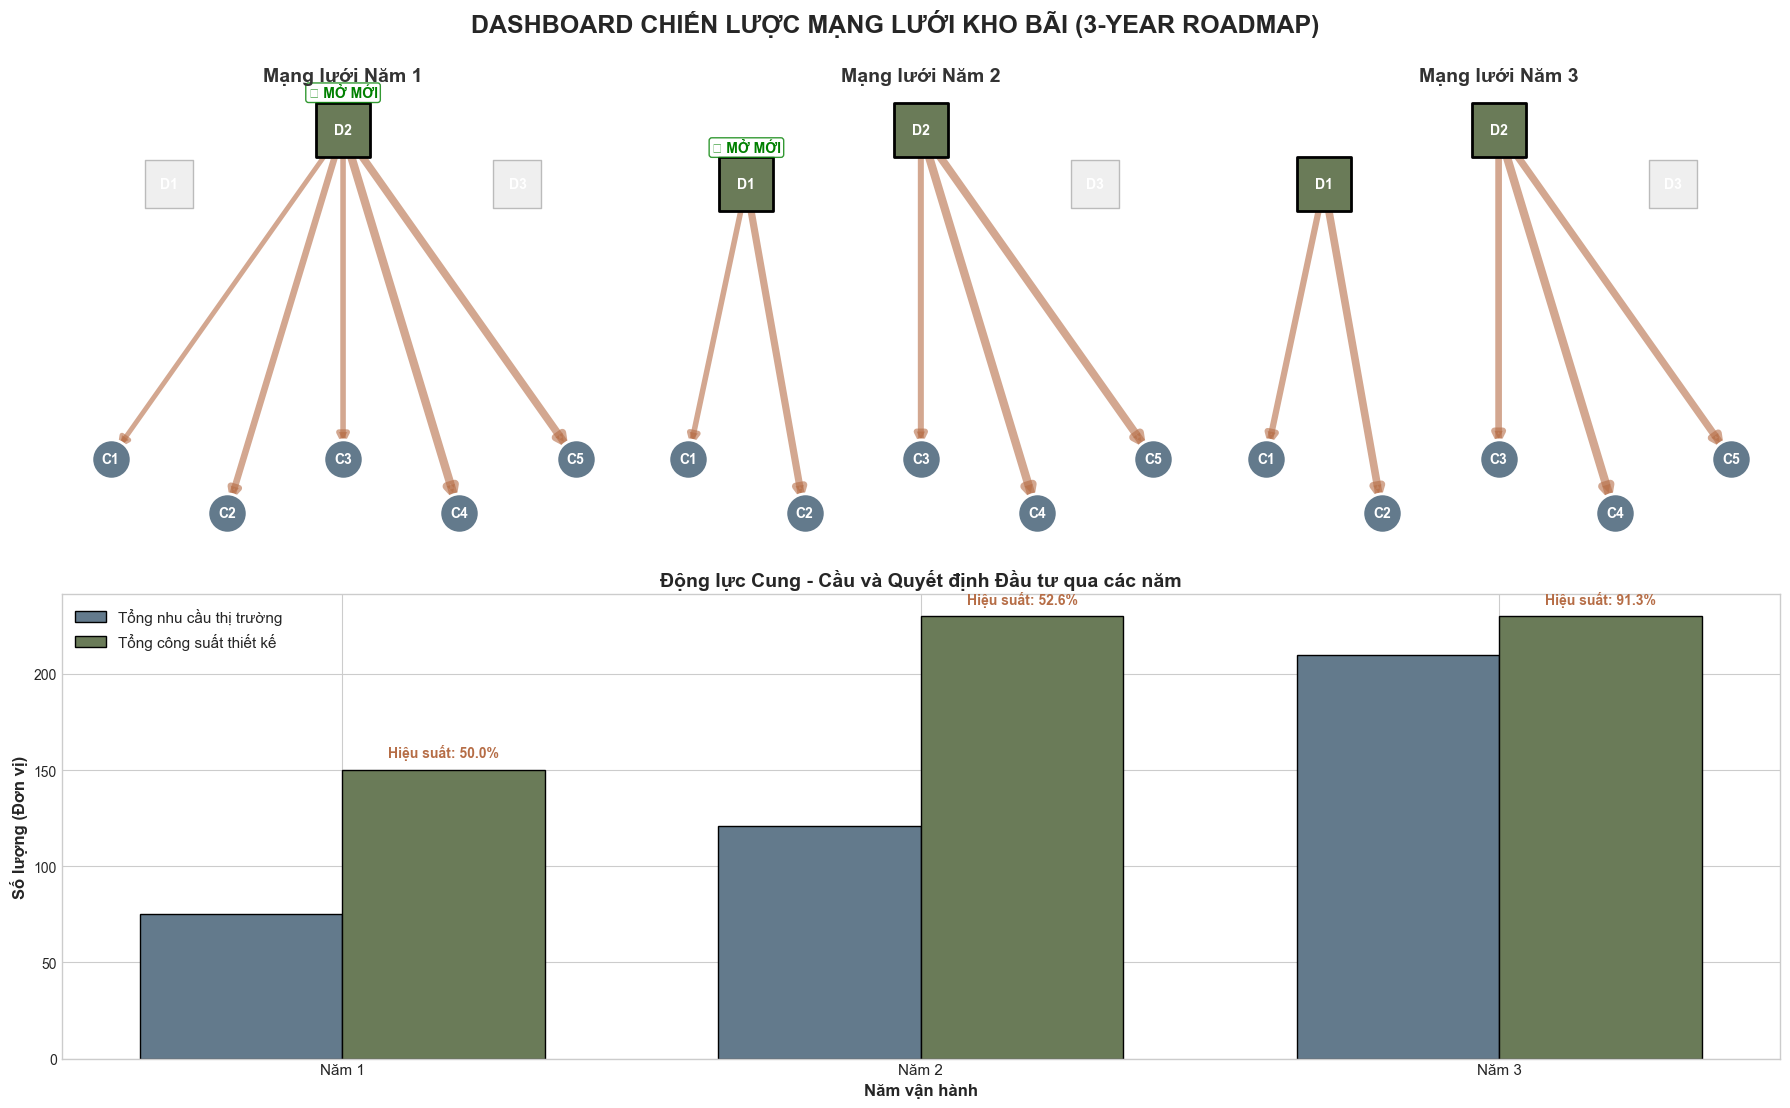

In [ ]:
# 5. TRỰC QUAN HÓA BẢN ĐỒ CHIẾN LƯỢC 3 NĂM
# Tọa độ giả định (để vẽ sơ đồ mạng lưới)
node_coords = {
    "D1": (2, 8), "D2": (5, 9), "D3": (8, 8),
    "C1": (1, 3), "C2": (3, 2), "C3": (5, 3), "C4": (7, 2), "C5": (9, 3)
}

# Cài đặt font và bố cục
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))
fig.suptitle("DASHBOARD CHIẾN LƯỢC MẠNG LƯỚI KHO BÃI (3-YEAR ROADMAP)", fontsize=18, fontweight='bold', y=0.95)

### 6. Appendix

C:\Users\Huy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\events.py:82: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Arial.
  func(*args, **kwargs)


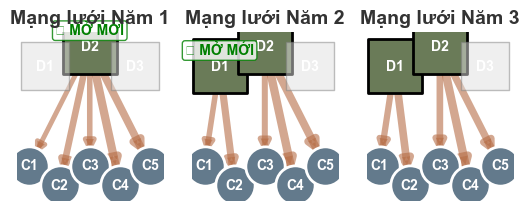

In [14]:
# PHẦN 1: BẢN ĐỒ TIẾN HÓA MẠNG LƯỚI (NETWORK EVOLUTION)
for idx, t in enumerate(YEARS):
    ax = plt.subplot(2, 3, idx + 1)
    G = nx.DiGraph()
    
    # Thêm nodes
    G.add_nodes_from(DEPOTS, bipartite=0)
    G.add_nodes_from(CLIENTS, bipartite=1)
    
    # Lọc danh sách kho hoạt động và đóng cửa
    active_depots = [j for j in DEPOTS if pulp.value(y[j][t]) > 0.5]
    closed_depots = [j for j in DEPOTS if pulp.value(y[j][t]) <= 0.5]
    
    # Lọc luồng hàng (Flow)
    edges = []
    edge_weights = []
    for j in active_depots:
        for i in CLIENTS:
            flow = pulp.value(x[i][j][t])
            if flow > 0.01:
                edges.append((j, i))
                edge_weights.append(flow)
    
    G.add_edges_from(edges)
    
    # Vẽ Khách hàng
    nx.draw_networkx_nodes(G, node_coords, nodelist=CLIENTS, node_color="#637A8C", 
                           node_size=800, node_shape="o", ax=ax, edgecolors="white", linewidths=2)
    # Vẽ Kho ĐANG HOẠT ĐỘNG
    nx.draw_networkx_nodes(G, node_coords, nodelist=active_depots, node_color="#6A7B58", 
                           node_size=1500, node_shape="s", ax=ax, edgecolors="black", linewidths=2)
    # Vẽ Kho ĐÓNG CỬA / CHƯA MỞ
    nx.draw_networkx_nodes(G, node_coords, nodelist=closed_depots, node_color="#E0E0E0", 
                           node_size=1200, node_shape="s", ax=ax, edgecolors="gray", linewidths=1, alpha=0.5)
    
    # Vẽ đường nối (độ dày tỷ lệ với lượng hàng flow)
    if edges:
        max_weight = max(edge_weights)
        normalized_weights = [(w / max_weight) * 5 + 1 for w in edge_weights]
        nx.draw_networkx_edges(G, node_coords, edgelist=edges, width=normalized_weights, 
                               alpha=0.6, edge_color="#B66D46", arrows=True, arrowsize=15, ax=ax)
    
    # Label tên Node
    nx.draw_networkx_labels(G, node_coords, font_size=10, font_weight="bold", font_color="white", ax=ax)
    
    # Label các hành động đặc biệt (Mở mới / Đóng cửa)
    for j in DEPOTS:
        if pulp.value(open_var[j][t]) > 0.5:
            ax.text(node_coords[j][0], node_coords[j][1] + 0.6, "✨ MỞ MỚI", 
                    color="green", fontweight="bold", ha="center", fontsize=10, 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='green', boxstyle='round,pad=0.2'))
        if pulp.value(close_var[j][t]) > 0.5:
            ax.text(node_coords[j][0], node_coords[j][1] + 0.8, "❌ ĐÓNG CỬA", 
                    color="red", fontweight="bold", ha="center", fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', boxstyle='round,pad=0.2'))

    ax.set_title(f"Mạng lưới Năm {t}", fontsize=14, fontweight='bold', color="#333333")
    ax.axis('off')

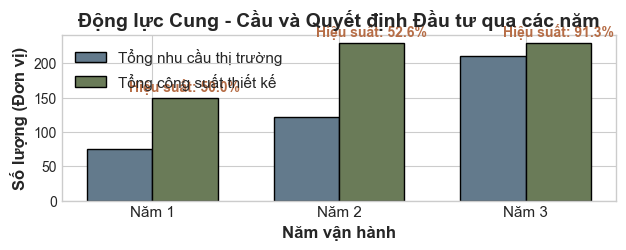

In [15]:
# PHẦN 2: BIỂU ĐỒ CÂN BẰNG CUNG - CẦU (CAPACITY VS DEMAND)
ax4 = plt.subplot(2, 1, 2)

total_demand_per_year = [sum(demand[t][i] for i in CLIENTS) for t in YEARS]
total_capacity_per_year = [sum(depot_data[j]["capacity"] * pulp.value(y[j][t]) for j in DEPOTS) for t in YEARS]

bar_width = 0.35
index = np.arange(len(YEARS))

# Bar Tổng Nhu Cầu
bar1 = ax4.bar(index, total_demand_per_year, bar_width, label='Tổng nhu cầu thị trường', color='#637A8C', edgecolor='black')

# Bar Tổng Công Suất
bar2 = ax4.bar(index + bar_width, total_capacity_per_year, bar_width, label='Tổng công suất thiết kế', color='#6A7B58', edgecolor='black')

ax4.set_xlabel('Năm vận hành', fontsize=12, fontweight='bold')
ax4.set_ylabel('Số lượng (Đơn vị)', fontsize=12, fontweight='bold')
ax4.set_title('Động lực Cung - Cầu và Quyết định Đầu tư qua các năm', fontsize=14, fontweight='bold')
ax4.set_xticks(index + bar_width / 2)
ax4.set_xticklabels([f"Năm {t}" for t in YEARS], fontsize=11)
ax4.legend(loc='upper left', fontsize=11)

# Ghi chú % Hiệu suất (Utilization)
for i in range(len(YEARS)):
    utilization = total_demand_per_year[i] / total_capacity_per_year[i] if total_capacity_per_year[i] > 0 else 0
    ax4.text(index[i] + bar_width, total_capacity_per_year[i] + 5, 
             f"Hiệu suất: {utilization:.1%}", ha='center', va='bottom', fontweight='bold', color="#B66D46")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()